In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings

import os
os.chdir("/Users/miguel.vidal_ladivin/Desktop")

data = pd.read_csv("recursos_humanos.csv")

data_encoded = pd.get_dummies(data, columns=['sales', 'salary'], drop_first=True)

columna = "left"
columnas = [columna] + [col for col in data_encoded.columns if col != columna]
data_final= data_encoded[columnas]

R = data_final[data_final.left == 1]
NR = data_final[data_final.left == 0]

x = data_final.drop("left", axis=1)
y = data_final["left"]
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

df_resampled = pd.DataFrame(x_resampled, columns=x.columns)
df_resampled['left'] = y_resampled

R_resampled = df_resampled[df_resampled.left == 1]
NR_resampled = df_resampled[df_resampled.left == 0]


In [6]:
df_resampled["left"].value_counts(normalize=True)

left
1    0.5
0    0.5
Name: proportion, dtype: float64

In [7]:
df_resampled

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,left
0,0.380000,0.530000,2,157,3,0,0,False,False,False,False,False,False,True,False,False,True,False,1
1,0.800000,0.860000,5,262,6,0,0,False,False,False,False,False,False,True,False,False,False,True,1
2,0.110000,0.880000,7,272,4,0,0,False,False,False,False,False,False,True,False,False,False,True,1
3,0.720000,0.870000,5,223,5,0,0,False,False,False,False,False,False,True,False,False,True,False,1
4,0.370000,0.520000,2,159,3,0,0,False,False,False,False,False,False,True,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22851,0.100000,0.980000,6,268,4,0,0,False,False,False,False,False,False,False,True,False,True,False,1
22852,0.400863,0.995470,2,277,3,0,0,True,False,False,False,False,False,False,False,False,False,True,1
22853,0.770795,0.958940,5,222,5,0,0,False,True,False,False,False,False,False,False,False,True,False,1
22854,0.416578,0.536711,2,145,3,0,0,False,False,False,False,False,False,False,True,False,True,False,1


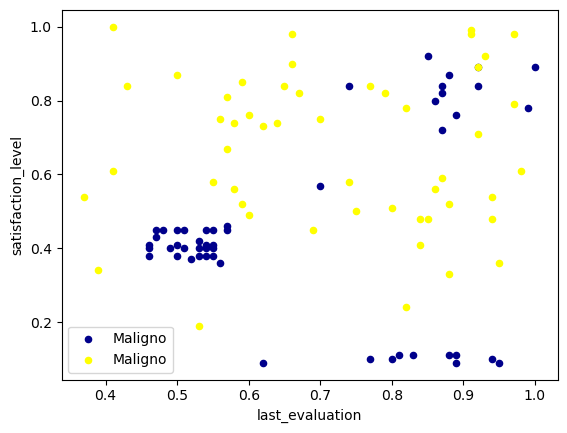

In [8]:
ax = df_resampled[df_resampled["left"] ==1][0:50].plot(kind="scatter", x="last_evaluation", y="satisfaction_level", color="Darkblue", label="Maligno");
ax = df_resampled[df_resampled["left"] ==0][0:50].plot(kind="scatter", x="last_evaluation", y="satisfaction_level", color="Yellow", label="Maligno", ax=ax);

plt.show()

In [9]:
NR_resampled

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,left
2000,0.58,0.74,4,215,3,0,0,False,False,False,False,False,False,True,False,False,True,False,0
2001,0.82,0.67,2,202,3,0,0,False,False,False,False,False,False,True,False,False,True,False,0
2002,0.45,0.69,5,193,3,0,0,False,False,False,False,False,False,True,False,False,True,False,0
2003,0.78,0.82,5,247,3,0,0,False,False,False,False,False,False,True,False,False,True,False,0
2004,0.49,0.60,3,214,2,0,0,False,False,False,False,False,False,True,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14206,0.90,0.55,3,259,10,1,1,False,False,False,True,False,False,False,False,False,False,False,0
14207,0.74,0.95,5,266,10,0,1,False,False,False,True,False,False,False,False,False,False,False,0
14208,0.85,0.54,3,185,10,0,1,False,False,False,True,False,False,False,False,False,False,False,0
14209,0.33,0.65,3,172,10,0,1,False,False,False,False,True,False,False,False,False,False,False,0


In [10]:
y = df_resampled.left.values
x_resampled = df_resampled.drop(["left"], axis = 1)

x = (x_resampled - np.min(x_resampled)) / (np.max(x_resampled) - np.min(x_resampled))
x

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.001226,0.001710,0.006452,0.506452,0.009677,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.003226,0.000000
1,0.002581,0.002774,0.016129,0.845161,0.019355,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.000000,0.003226
2,0.000355,0.002839,0.022581,0.877419,0.012903,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.000000,0.003226
3,0.002323,0.002806,0.016129,0.719355,0.016129,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.003226,0.000000
4,0.001194,0.001677,0.006452,0.512903,0.009677,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.003226,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22851,0.000323,0.003161,0.019355,0.864516,0.012903,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.003226,0.0,0.003226,0.000000
22852,0.001293,0.003211,0.006452,0.893548,0.009677,0.0,0.0,0.003226,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.003226
22853,0.002486,0.003093,0.016129,0.716129,0.016129,0.0,0.0,0.000000,0.003226,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.003226,0.000000
22854,0.001344,0.001731,0.006452,0.467742,0.009677,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.003226,0.0,0.003226,0.000000


In [11]:
df_resampled.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
promotion_last_5years      int64
sales_RandD                 bool
sales_accounting            bool
sales_hr                    bool
sales_management            bool
sales_marketing             bool
sales_product_mng           bool
sales_sales                 bool
sales_support               bool
sales_technical             bool
salary_low                  bool
salary_medium               bool
left                       int64
dtype: object

In [12]:
feature_df = df_resampled[["satisfaction_level", "last_evaluation","number_project","average_montly_hours","time_spend_company","Work_accident","promotion_last_5years","sales_RandD","sales_accounting","sales_hr","sales_management","sales_marketing","sales_product_mng","sales_sales","sales_support","sales_technical","salary_low","salary_medium"]]
x = np.asarray(feature_df)
x[0:5]

array([[0.38, 0.53, 2, 157, 3, 0, 0, False, False, False, False, False,
        False, True, False, False, True, False],
       [0.8, 0.86, 5, 262, 6, 0, 0, False, False, False, False, False,
        False, True, False, False, False, True],
       [0.11, 0.88, 7, 272, 4, 0, 0, False, False, False, False, False,
        False, True, False, False, False, True],
       [0.72, 0.87, 5, 223, 5, 0, 0, False, False, False, False, False,
        False, True, False, False, True, False],
       [0.37, 0.52, 2, 159, 3, 0, 0, False, False, False, False, False,
        False, True, False, False, True, False]], dtype=object)

In [13]:
df_resampled["left"] = df_resampled["left"].astype("int")
y = np.asarray(df_resampled["left"])
y[0:5]

array([1, 1, 1, 1, 1])

In [14]:
x_train, x_test, y_train, y_test =  train_test_split(x, y, test_size = 0.3, random_state=4)
print ("Grupo de entrenamiento", x_train.shape, y_train.shape) #cuantos renglone sy columnas hay en el grupo
print ("Grupo de prueba", x_test.shape, y_test.shape)

Grupo de entrenamiento (15999, 18) (15999,)
Grupo de prueba (6857, 18) (6857,)


In [15]:
# RBF
from sklearn import svm
clf = svm.SVC(kernel="rbf")
clf.fit(x_train, y_train)

SVC()

In [16]:
# Prediccion para la base de prueba
y_hat = clf.predict(x_test)
y_hat[0:5]

array([0, 1, 0, 0, 0])

In [17]:
# Creación de matriz de confusion
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, y_hat)
cm

array([[2369, 1052],
       [1061, 2375]], dtype=int64)

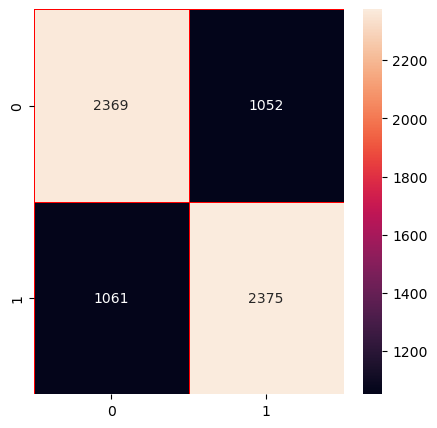

In [18]:
# Visualizar la matriz de confusion
import seaborn as sns
f , ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel =("y pronosticada")
plt.ylabel= ("y real")

In [19]:
# Estadisiticas de desempeño
from sklearn.metrics import classification_report
cnf_matrix = confusion_matrix(y_test, y_hat, labels=[0,1])
print (classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.69      0.69      0.69      3421
           1       0.69      0.69      0.69      3436

    accuracy                           0.69      6857
   macro avg       0.69      0.69      0.69      6857
weighted avg       0.69      0.69      0.69      6857



In [21]:
# Dterminación de niveles de precision (precision) porcentaje de predicciones correctas relativas al total de predicciones
# total esta calculado por columna, se contesta a la pregunta siguiente:
#¿que porcentaje de las veces que hacemos que un pronostico de cierto tipo este es correcto?

In [24]:
precisionNR = cm[0,0] / (cm[0,0] + cm[1,0])
precisionNR

0.6906705539358601

In [25]:
precisionR = cm[1,1] / (cm[1,1] + cm[0,1])
precisionR

0.6930259702363584

In [26]:
# Determinación de niveles de recuperación "recall"
#La recuperación o recall es el porcentaje de predicciones correctas relativas al total de valores reales.
#El total se calcula lor renglo y no por columna
#Se contesta a la pregunta ¿que porcentaje de las veces que se tiene un valor es capaz de identificar?

In [29]:
recallNR = cm[0,0] / (cm[0,0] + cm[0,1])
recallNR

0.6924875767319497

In [31]:
recallR = cm[1,1] / (cm[1,1] + cm[1,0])
recallR

0.6912107101280559

In [36]:
# Determinación de score F1
#f1_score = media armonica ponderada de la precisión y el nivel de recuperación, mas cercano a 1 es mejor.
# f1 score se calcula de la siguiente manera = 2 * (precision*recall) / (precision + recall)



In [37]:
f1NR = 2 * (precisionNR * recallNR) / (precisionNR + recallNR)
f1NR

0.6915778718435265

In [38]:
f1R = 2 * (precisionR * recallR) / (precisionR + recallR)
f1R

0.6921171499344312

In [39]:
# Determinación de soportes = numero de observaciones que pertenecen en forma real a cada clase posible (total * renglon)


In [40]:
soporteNR = cm[0,0] + cm[0,1]
soporteNR

3421

In [41]:
soporteR = cm[1,0] + cm[1,1]
soporteR

3436

In [42]:
# Detemrinación de la precision global (accuracy)
# Es el porcentaje de predicciones correctas en lo general

In [43]:
correctos = cm[0,0] + cm[1,1]
incorrectos = cm[0,1] + cm[1,0]
precisionglobal = correctos / (correctos + incorrectos)
precisionglobal

0.6918477468280589

In [44]:
# Promedio simple por indicador (macro average)
# promedio simple por precision, recuperación y f1 score
 

In [45]:
macroavgprecision = (precisionNR + precisionR) / 2
macroavgprecision

0.6918482620861093

In [46]:
macroavgrecall = (recallNR + recallR) / 2
macroavgrecall

0.6918491434300028

In [47]:
macroavgf1 = (f1NR + f1R) / 2
macroavgf1

0.6918475108889788

In [48]:
# Promedos ponderados por indcador (weigthed average)
# promedios ponderados de acuerdo a soportes por indicador

In [49]:
pesoNR = soporteNR / (soporteNR + soporteR)
pesoR = soporteR / (soporteNR + soporteR)

In [50]:
Wavgprecision = precisionNR * pesoNR + precisionR * pesoR
Wavgprecision

0.6918508383763606

In [51]:
Wavgrecall = recallNR * pesoNR + recallR * pesoR
Wavgrecall

0.6918477468280588

In [52]:
Wavgf1 = f1NR * pesoNR + f1R * pesoR
Wavgf1

0.6918481007366792

In [107]:
#Polynomial
from sklearn import svm
clf = svm.SVC(kernel="poly")
clf.fit(x_train, y_train)

y_hat = clf.predict(x_test)

#Matriz de confusion
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, y_hat)
cm




array([[3022,  399],
       [1707, 1729]], dtype=int64)

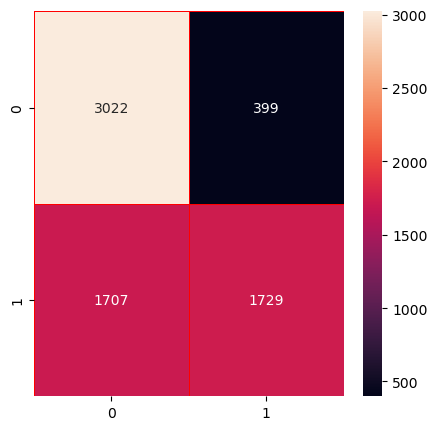

In [109]:
# Visualizar la matriz de confusion
import seaborn as sns
f , ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel =("y pronosticada")
plt.ylabel= ("y real")

In [111]:
from sklearn.metrics import classification_report
cnf_matrix = confusion_matrix(y_test, y_hat, labels=[0,1])
print (classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.64      0.88      0.74      3421
           1       0.81      0.50      0.62      3436

    accuracy                           0.69      6857
   macro avg       0.73      0.69      0.68      6857
weighted avg       0.73      0.69      0.68      6857



In [113]:
#Sigmoide
from sklearn import svm
clf = svm.SVC(kernel="sigmoid")
clf.fit(x_train, y_train)

y_hat = clf.predict(x_test)

#Matriz de confusion
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, y_hat)
cm


array([[1620, 1801],
       [1812, 1624]], dtype=int64)

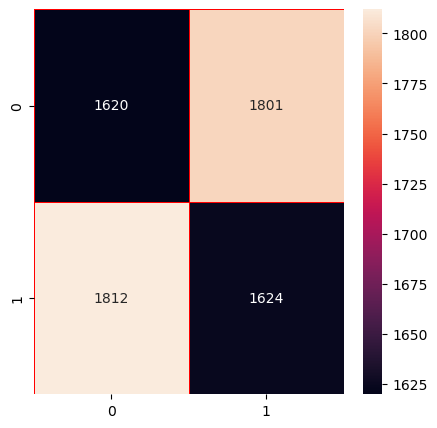

In [115]:
# Visualizar la matriz de confusion
import seaborn as sns
f , ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel =("y pronosticada")
plt.ylabel= ("y real")

In [117]:
from sklearn.metrics import classification_report
cnf_matrix = confusion_matrix(y_test, y_hat, labels=[0,1])
print (classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.47      0.47      0.47      3421
           1       0.47      0.47      0.47      3436

    accuracy                           0.47      6857
   macro avg       0.47      0.47      0.47      6857
weighted avg       0.47      0.47      0.47      6857



In [119]:
from sklearn.svm import LinearSVC
clf = LinearSVC(max_iter=10000)
clf.fit(x_train, y_train)

y_hat = clf.predict(x_test)

#Matriz de confusion
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, y_hat)
cm


array([[2595,  826],
       [ 630, 2806]], dtype=int64)

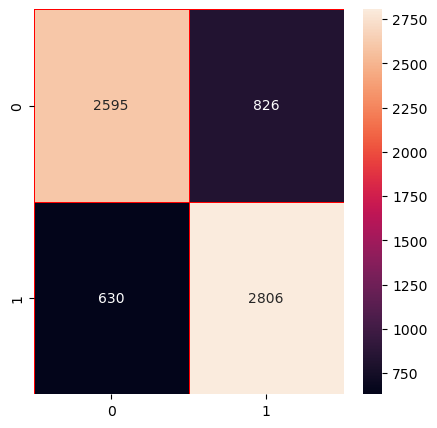

In [121]:
# Visualizar la matriz de confusion
import seaborn as sns
f , ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel =("y pronosticada")
plt.ylabel= ("y real")

In [123]:
from sklearn.metrics import classification_report
cnf_matrix = confusion_matrix(y_test, y_hat, labels=[0,1])
print (classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78      3421
           1       0.77      0.82      0.79      3436

    accuracy                           0.79      6857
   macro avg       0.79      0.79      0.79      6857
weighted avg       0.79      0.79      0.79      6857



In [98]:
# Nuevo empleado
nuevo_empleado = {
    "satisfaction_level": 0.5,
    "last_evaluation": 0.75,
    "number_project": 4,
    "average_montly_hours": 200,
    "time_spend_company": 4,
    "Work_accident": 0,
    "promotion_last_5years": 0,
    "sales": "sales",
    "salary": "medium"
}

nuevo_df = pd.DataFrame([nuevo_empleado])

nuevo_df = pd.get_dummies(nuevo_df, columns=['sales', 'salary'])

# Columnas que el modelo espera (extraídas de tus datos de entrenamiento)
columnas_modelo = feature_df.columns  # x es tu matriz de entrenamiento después de SMOTE y normalización

# Asegurar que todas estén en el nuevo DataFrame
for col in columnas_modelo:
    if col not in nuevo_df.columns:
        nuevo_df[col] = 0  # Agrega la columna faltante con valor 0

# Ordenar las columnas igual que el modelo
nuevo_df = nuevo_df[columnas_modelo]

# Normalización usando el mismo x original
nuevo_df = (nuevo_df - x.min()) / (x.max() - x.min())

prediccion = clf.predict(nuevo_df)
print("¿El empleado dejaría la empresa?", "Sí" if prediccion[0] == 1 else "No")

¿El empleado dejaría la empresa? No


C:\Users\miguel.vidal_ladivin\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearSVC was fitted without feature names
  warnings.warn(
